In [1]:
from datasets import load_dataset
import tiktoken
import torch
import humanize
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
from IPython.display import clear_output
from IPython import display
from pathlib import Path

def ensure_file(file_path):
  base_path = Path(file_path).parent
  Path(base_path).mkdir(parents=True, exist_ok=True)
  return file_path

def get_line_stats(batch, tokenizer):
  tokens_batch = []
  length_batch = []
  for row in batch["text"]:
    tokens = tokenizer.encode(row, allowed_special={"<|endoftext|>"})
    tokens_batch.append(tokens)
    length_batch.append(len(tokens))
  return {"tokens": tokens_batch, "length": length_batch}

def prepare_dataset(name, cache_file, tokenizer, pad_token, seq_len):
  # Load the dataset and gather token lengths
  dataset = load_dataset(name, split="train")
  dataset = dataset.map(
    lambda b: get_line_stats(b, tokenizer),
    batched=True,
    remove_columns=["text"]
  )

  # Pad each token sequence into a fixed size
  max_len = max(dataset["length"]) + 1
  nearest_multiple = ((max_len // seq_len) + 1) * seq_len if max_len % seq_len != 0 else max_len
  shape = (len(dataset), nearest_multiple)

  padded = torch.full(shape, pad_token, dtype=torch.int)
  for i, tokens in enumerate(dataset["tokens"]):
    padded[i, :len(tokens)] = torch.tensor(tokens, dtype=torch.int)

  # Split each sequence into chunks and cache them
  num_chunks = padded.shape[1] // seq_len
  chunks = torch.chunk(padded, chunks=num_chunks, dim=1)
  torch.save(chunks, cache_file)
  return chunks[0].shape[0], chunks

In [2]:
def init_weights(module):
  if isinstance(module, nn.Linear):
    nn.init.kaiming_normal_(module.weight)
    if module.bias is not None:
      nn.init.constant_(module.bias, 0.0)

def paramtensor(size, scale, residual_scale=1.0):
  total_scale = scale * residual_scale
  return nn.Parameter(torch.randn(*size) * total_scale)

class Decoder(nn.Module):
  # B x T x E input and output, where B is the batch size, T is the token
  # sequence length and E is the embedding dimension.
  def __init__(self, E, H, D_k, D_f, L):
    super().__init__()
    self.H, self.D_k = H, D_k
    # Because LayerNorm is the first stage of a dcoder block, there needs to be
    # a way to stop variance from exploding as the model gets deeper. Scaling by
    # 1 / sqrt(2 * L), where L is the number of decoder layers and 2 refers to the
    # 2 residual connections present in a decoder layer ensures that the variance
    # remains a constant 2.
    res_scale = 1 / math.sqrt(2.0 * L)
    kaiming_scale = math.sqrt(2.0 / E)
    kaiming_scale_out = math.sqrt(2.0 / (D_k * H))

    # Linear projection matrices for the query, key and value
    # B x T x E -> B x H x T x D_k, where H is the number of attention heads and
    # D_k is the query, key and value embedding dimension for each attention head
    self.Q_proj = paramtensor((E, D_k * H), kaiming_scale)
    self.K_proj = paramtensor((E, D_k * H), kaiming_scale)
    self.V_proj = paramtensor((E, D_k * H), kaiming_scale)
    # Output projection for the scaled values of the concatenated attention heads
    self.O_proj = paramtensor((D_k * H, E), kaiming_scale_out, residual_scale=res_scale)

    self.norm1 = nn.LayerNorm(E) # After the multihead self-attention
    self.norm2 = nn.LayerNorm(E) # After the feed forward network

    # Feed forward network: B x T x E -> B x T x D_f -> B x T x E,
    # where D_f is the dimension of the hidden layer
    self.ffn = nn.Sequential(nn.Linear(E, D_f), nn.ReLU(), nn.Linear(D_f, E))

    # Scale the final feed forward layer by the residual scale
    with torch.no_grad():
      self.ffn[2].weight.mul_(res_scale)

  def forward(self, x, M):
    norm_x1 = self.norm1(x)

    # Linearly project queries, keys and value for each attention head, perform
    # multi-head masked self-attention on the input, each concatenate each attention
    # head's values and linearly project them back into embedding space.
    B, T = x.shape[0], x.shape[1]
    Q = (norm_x1 @ self.Q_proj).reshape(B, T, self.H, self.D_k).transpose(1, 2)
    K = (norm_x1 @ self.K_proj).reshape(B, T, self.H, self.D_k).transpose(1, 2)
    V = (norm_x1 @ self.V_proj).reshape(B, T, self.H, self.D_k).transpose(1, 2)

    # The causal mask ensures that future tokens can't be attended to since e^-inf approaches 0.
    scaled = F.scaled_dot_product_attention(Q, K, V, attn_mask=M)
    # Concatenate each attention head and linearly project the result back into embedding space
    attended = scaled.transpose(1, 2).reshape(B, T, self.H * self.D_k) @ self.O_proj

    # Process the attended values
    x = attended + x
    norm_x2 = self.norm2(x)
    return self.ffn(norm_x2) + x

class Transformer(nn.Module):
  # B x T input and B x T x V output, where B is the batch size, T is the token
  # sequence length. Each token is an index into the vocabulary (V).
  def __init__(self, V, E, T, H, D_k, D_f, L, device):
    super().__init__()
    # Embeddings: B x T -> B x T x E, where E is the embedding dimension
    kaiming_scale = math.sqrt(2.0 / E)
    self.tok_embed = paramtensor((V, E), kaiming_scale)
    self.pos_embed = paramtensor((T, E), kaiming_scale)
    self.E_scale = math.sqrt(E)

    # Share the same causal mask for all decoders to save memory
    temp = torch.full((T, T), float("-inf"), device=device)
    self.causal_mask = torch.triu(temp, diagonal=1).to(device)

    # Transformer decoder layers are referred to as decoders because of their
    # auto-regressive masked self-attention, not because of their structure.
    self.layers = nn.ModuleList([Decoder(E, H, D_k, D_f, L) for _ in range(L)])

    self.final_norm = nn.LayerNorm(E)

  def forward(self, x):
    # Each token selects a row from the learned token embedding matrix.
    embeddings = self.tok_embed[x] * self.E_scale + self.pos_embed

    for layer in self.layers:
      embeddings = layer(embeddings, self.causal_mask)
    embeddings = self.final_norm(embeddings)

    # Convert embeddings back into tokens by creating a B x T x V logit matrix. During
    # training, the difference between the actual next token and the most probable next
    # token will be minimized. During inference, the next most probable token will be selected.
    return embeddings @ self.tok_embed.T

In [3]:
dataset_name = "BabyLM-community/BabyLM-2026-Strict-Small"
data_cache_file = ensure_file(".cache/prepared-dataset.pth")
model_cache_file = ensure_file(".cache/model-weights.pth")
hyperparams = {
  "embedding_dim": 512, "num_attn_heads": 12, "attn_dim": 64,
  "ffn_dim": 2048, "seq_len": 512, "num_layers": 12, "batch_size": 16,
  "train_steps": 1000, "warmup_steps": 300, "test_steps": 10,
  "train_split": 0.5
}
experiment_name = "Tiny GPT"

# EOS token = Pad token to minimize the vocab size
tokenizer = tiktoken.encoding_for_model("gpt2")
eos_token = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]

device = "cuda" if torch.cuda.is_available() else "cpu"
model = Transformer(
  tokenizer.n_vocab,
  hyperparams["embedding_dim"],
  hyperparams["seq_len"],
  hyperparams["num_attn_heads"],
  hyperparams["attn_dim"],
  hyperparams["ffn_dim"],
  hyperparams["num_layers"],
  device
).to(device)
model.apply(init_weights)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

try:
  chunks = torch.load(data_cache_file)
  total_rows = chunks[0].shape[0]
except:
  total_rows, chunks = prepare_dataset(dataset_name, data_cache_file,
                           tokenizer, eos_token, hyperparams["seq_len"])

train_split = int(hyperparams["train_split"] * total_rows)
print(f"Using {device} to train a {humanize.intword(num_params)} parameter model.")

README.md: 0.00B [00:00, ?B/s]

bnc_spoken.train.txt: 0.00B [00:00, ?B/s]

childes.train.txt:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

gutenberg.train.txt:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

open_subtitles.train.txt:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

simple_wiki.train.txt: 0.00B [00:00, ?B/s]

switchboard.train.txt: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1104106 [00:00<?, ? examples/s]

Map:   0%|          | 0/1104106 [00:00<?, ? examples/s]

Using cuda to train a 70.1 million parameter model.


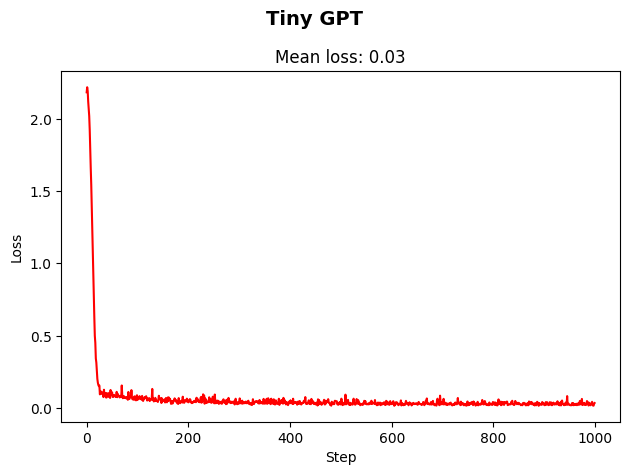

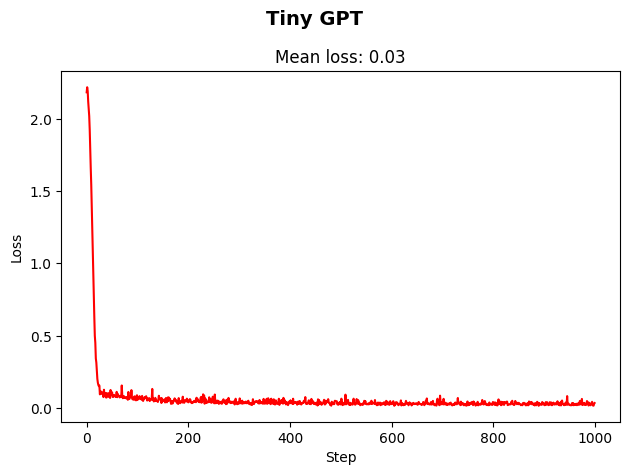

In [4]:
def custom_learning_rate(step):
  ws, ts = hyperparams["warmup_steps"], hyperparams["train_steps"]

  # Linear warmup phase
  if step < ws:
    return float(step) / float(max(1, ws))

  # Cosine decay phase
  progress = float(step - ws) / float(max(1, ts - ws))
  return 0.5 * (1.0 + math.cos(math.pi * progress))

model.train()
torch.enable_grad()

optimizer = AdamW(model.parameters(), lr=3e-5, betas=(0.9, 0.98), eps=1e-9)
criterion = nn.CrossEntropyLoss()
scheduler = LambdaLR(optimizer, custom_learning_rate)

fig, ax = plt.subplots()
step_losses = []

# Training loop
for step in range(hyperparams["train_steps"]):
  indices = torch.randint(low=0, high=train_split, size=(hyperparams["batch_size"],))
  chunk_losses = []

  for j in range(len(chunks)):
    # The correct next token is the sequence shifted to the left
    rows = chunks[j][indices].to(device)
    target = torch.full(rows.shape, eos_token, dtype=torch.long, device=device)
    target[:, :-1] = rows[:, 1:]

    with torch.autocast(device_type=device, dtype=torch.bfloat16):
      prediction = model(rows)
      # Flatten tensors to make CrossEntropyLoss work well:
      # prediction: B x T x V -> B * T x V, target: B x T -> 1 x B * T
      loss = criterion(
        prediction.reshape(-1, prediction.shape[-1]),
        target.reshape(-1)
      )

    chunk_losses.append(loss.item())
    (loss / len(chunks)).backward() # Average the loss across chunks

  # Average gradients across different chunks of the same sequence
  optimizer.step()
  optimizer.zero_grad(set_to_none=True)
  scheduler.step()

  # Plot a loss curve in real time
  mean_loss = sum(chunk_losses) / len(chunk_losses)
  step_losses.append(mean_loss)

  clear_output(wait=True)
  ax.clear()
  ax.plot(step_losses, "r-")
  ax.autoscale_view(scalex=True, scaley=True)
  fig.suptitle(experiment_name, fontsize=14, fontweight="bold")
  ax.set_title(f"Mean loss: {mean_loss:.2f}")
  ax.set_xlabel("Step")
  ax.set_ylabel("Loss")

  fig.tight_layout() # Prevents overlapping labels
  display.display(fig)

torch.save(model.state_dict(), model_cache_file)
fig.savefig(f"{experiment_name}.png", dpi=300, bbox_inches="tight")

In [5]:
model.eval()
torch.set_grad_enabled(False)

# Test loop
test_losses = []
for _ in range(hyperparams["test_steps"]):
  indices = torch.randint(low=train_split, high=total_rows, size=(hyperparams["batch_size"],))
  chunk_losses = []

  for j in range(len(chunks)):
    rows = chunks[j][indices].to(device)
    target = torch.full(rows.shape, eos_token, dtype=torch.long, device=device)
    target[:, :-1] = rows[:, 1:]

    with torch.autocast(device_type=device, dtype=torch.bfloat16):
      prediction = model(rows)
      loss = criterion(
        prediction.reshape(-1, prediction.shape[-1]),
        target.reshape(-1)
      )

    chunk_losses.append(loss.item())

  test_losses.append(sum(chunk_losses) / len(chunk_losses))

print("Mean test loss:", sum(test_losses) / len(test_losses))
torch.set_grad_enabled(True)

Mean test loss: 0.07984514251972238


torch.autograd.grad_mode.set_grad_enabled(mode=True)